17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training RNN ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.5634 - loss: 0.6771 - val_accuracy: 0.6134 - val_loss: 0.6446
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.7733 - loss: 0.4872 - val_accuracy: 0.8180 - val_loss: 0.4274
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.8904 - loss: 0.2697 - val_accuracy: 0.8202 - val_loss: 0.4275
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.9502 - loss: 0.1406 - val_accuracy: 0.8252 - val_loss: 0.4805
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9868 - loss: 0.0490 - val_accuracy: 0.8116 - val_loss: 0.6051

--- Training LSTM ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.7559 - loss: 0.4886 - val_accuracy: 0.8350 - val_loss: 0.3952
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.8891 - loss: 0.2818 - val_accuracy: 0.8696 - val_loss: 0.3125

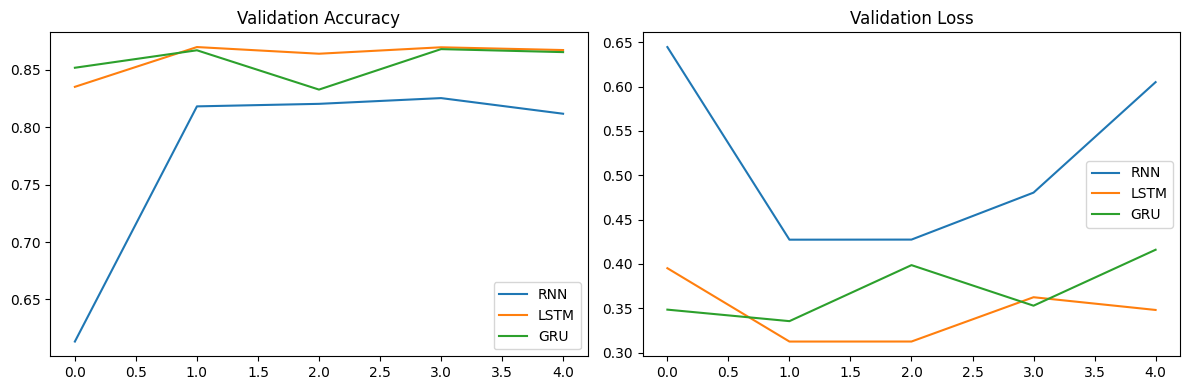


{'Model':<8} {'Accuracy':>10} {'Loss':>8} {'Time(s)':>10}
RNN          0.8131   0.6018       80.0
LSTM         0.8535   0.3783      246.1
GRU          0.8530   0.4557      315.8


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import time

# Load IMDB dataset
MAX_FEATURES = 10000
MAX_LEN = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN)

def build_model(rnn_type):
    model = Sequential()
    model.add(tf.keras.layers.Embedding(MAX_FEATURES, 32))
    if rnn_type == 'RNN':
        model.add(SimpleRNN(64))
    elif rnn_type == 'LSTM':
        model.add(LSTM(64))
    elif rnn_type == 'GRU':
        model.add(GRU(64))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

results = {}
histories = {}

for rnn_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n--- Training {rnn_type} ---")
    model = build_model(rnn_type)
    start = time.time()
    history = model.fit(x_train, y_train,
                        epochs=5,
                        batch_size=128,
                        validation_split=0.2,
                        verbose=1)
    elapsed = time.time() - start
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[rnn_type] = {'accuracy': acc, 'loss': loss, 'time': elapsed}
    histories[rnn_type] = history

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for rnn_type, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=rnn_type)
    axes[1].plot(h.history['val_loss'],     label=rnn_type)
axes[0].set_title('Validation Accuracy')
axes[0].legend()
axes[1].set_title('Validation Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('rnn_comparison.png')
plt.show()

# Print summary table
print("\n{'Model':<8} {'Accuracy':>10} {'Loss':>8} {'Time(s)':>10}")
for k, v in results.items():
    print(f"{k:<8} {v['accuracy']:>10.4f} {v['loss']:>8.4f} {v['time']:>10.1f}")
